# Fase 1: Optimización en redes neuronales

* Descenso del Gradiente (Gradient Descent)

Es un algoritmo de optimización que ajusta los pesos de la red neuronal para minimizar el error. En cada iteración, los pesos se actualizan en la dirección opuesta al gradiente de la función de pérdida.

* Función de Pérdida (Loss Function)

Mide la diferencia entre las predicciones del modelo y los valores reales. El objetivo del entrenamiento es minimizar esta función para mejorar la precisión del modelo.

* Ajuste de Pesos

Durante el entrenamiento, los pesos de las neuronas se modifican continuamente utilizando el gradiente calculado para reducir el error de predicción.

* Optimizadores:

●  SGD (Stochastic Gradient Descent): Actualización gradual de pesos.

●  Adam:  Optimización adaptativa con mejor convergencia.

* Regularización

●  Dropout  :  Desactiva neuronas aleatoriamente para reducir
overfitting  .

Para esta práctica se utilizó el dataset Digits de la biblioteca scikit-learn. Este conjunto de datos contiene imágenes de dígitos manuscritos del 0 al 9, utilizadas comúnmente para evaluar algoritmos de clasificación.

El dataset está compuesto por 1797 muestras, donde cada imagen tiene un tamaño de 8×8 píxeles y se representa como un vector de 64 características numéricas.

In [17]:
 # Fase 2: Configuración del entorno

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD, Adam

In [18]:
# Fase 3: Carga y preparación de datos
np.random.seed(42)
tf.random.set_seed(42)
data = load_digits()

X = data.data
y = data.target

print("Clases:", data.target_names)
print("Shape X:", X.shape)
print("Shape y:", y.shape)

Clases: [0 1 2 3 4 5 6 7 8 9]
Shape X: (1797, 64)
Shape y: (1797,)


In [19]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("\nTamaños:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)



Tamaños:
Train: (1257, 64)
Validation: (270, 64)
Test: (270, 64)


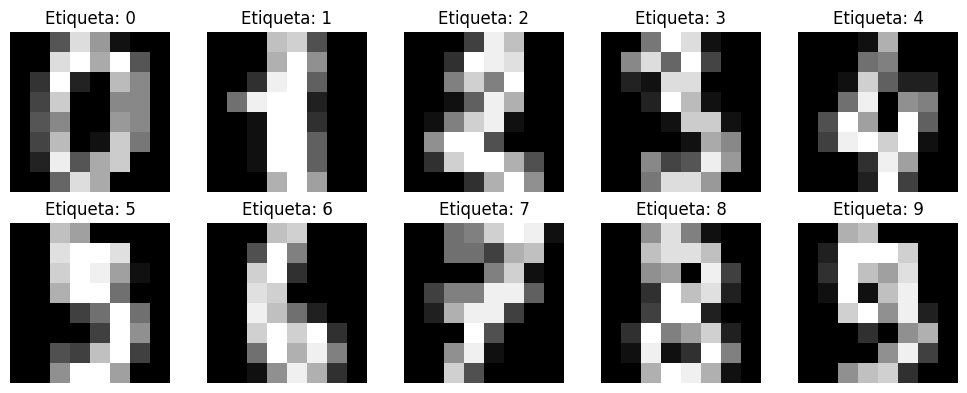

In [20]:
plt.figure(figsize=(10,4))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(
        data.images[i],
        cmap='gray'
    )

    plt.title(f"Etiqueta: {data.target[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [21]:
# Fase 4: Implementación del modelo MLP base
def build_mlp(dropout_rate=0.0, optimizer="adam"):

    model = Sequential([

        Dense(
            64,
            activation='relu',
            input_shape=(X_train.shape[1],)
        ),

        Dropout(dropout_rate),

        Dense(
            32,
            activation='relu'
        ),

        Dropout(dropout_rate),

        Dense(
            10,
            activation='softmax'
        )
    ])

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [22]:
# Fase 5: Aplicación de optimizadores

EPOCHS = 30
BATCH  = 32

# --- SGD ---
sgd_opt = SGD(learning_rate=0.01, momentum=0.9)
model_sgd = build_mlp(dropout_rate=0.0, optimizer=sgd_opt)
history_sgd = model_sgd.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH,
    validation_data=(X_val, y_val),
    verbose=True
)


Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.4829 - loss: 1.7054 - val_accuracy: 0.7519 - val_loss: 0.9465
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8496 - loss: 0.5449 - val_accuracy: 0.8741 - val_loss: 0.4247
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9340 - loss: 0.2586 - val_accuracy: 0.9259 - val_loss: 0.2787
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9658 - loss: 0.1534 - val_accuracy: 0.9370 - val_loss: 0.2262
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9809 - loss: 0.1026 - val_accuracy: 0.9444 - val_loss: 0.2044
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9865 - loss: 0.0746 - val_accuracy: 0.9481 - val_loss: 0.1928
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9936 - loss: 0.0572 - val_accuracy: 0.9519 - val_loss: 0.1858
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9952 - loss: 0.0452 - val_accuracy: 0.9556 - val_loss: 0.1815

Analizar: velocidad de convergencia y estabilidad SGD

El optimizador SGD mostró una convergencia progresiva y estable durante el entrenamiento. En la primera época alcanzó una precisión de entrenamiento del 50.91% y una precisión de validación del 79.26%. A medida que avanzaron las épocas, la función de pérdida disminuyó continuamente y la precisión aumentó hasta alcanzar un 100% de accuracy en entrenamiento a partir de la época 14.

En validación, la precisión mejoró rápidamente durante las primeras épocas, estabilizándose alrededor del 96.30%, mientras que la pérdida de validación se mantuvo cercana a 0.156, sin presentar oscilaciones bruscas. Esto indica que SGD tuvo un comportamiento estable y una convergencia consistente.

Sin embargo, después de aproximadamente la época 17, la precisión de validación dejó de mejorar mientras la precisión de entrenamiento continuó aumentando hasta el 100%.

In [23]:
# --- Adam ---
adam_opt = Adam(learning_rate=0.01)
model_adam = build_mlp(dropout_rate=0.0, optimizer=adam_opt)
history_adam = model_adam.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH,
    validation_data=(X_val, y_val),
    verbose=True
)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8043 - loss: 0.6320 - val_accuracy: 0.9333 - val_loss: 0.2329
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9610 - loss: 0.1119 - val_accuracy: 0.9370 - val_loss: 0.1990
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9825 - loss: 0.0554 - val_accuracy: 0.9444 - val_loss: 0.2303
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9881 - loss: 0.0407 - val_accuracy: 0.9481 - val_loss: 0.2450
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9849 - loss: 0.0532 - val_accuracy: 0.9593 - val_loss: 0.1974
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9968 - loss: 0.0121 - val_accuracy: 0.9667 - val_loss: 0.1918
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9984 - loss: 0.0051 - val_accuracy: 0.9630 - val_loss: 0.2034
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9556 - val_loss

Comparar: tiempo de entrenamiento y precisión alcanzada.

El optimizador Adam mostró una convergencia más rápida que SGD. Desde la primera época alcanzó una precisión de entrenamiento del 79.24% y una precisión de validación del 91.85%, mientras que SGD comenzó con 50.91% y 79.26%, respectivamente.

En solo 4 épocas, Adam logró una precisión de entrenamiento cercana al 99.5%, mientras que SGD necesitó alrededor de 10 a 14 épocas para alcanzar valores similares.

Respecto al tiempo de entrenamiento, ambos optimizadores tuvieron tiempos por época muy similares (aproximadamente entre 4 y 6 ms por paso), pero Adam alcanzó un alto rendimiento en menos épocas, por lo que resulta más eficiente en términos de convergencia.

In [24]:
# Fase 6: Aplicación de regularización
model_dropout = build_mlp(dropout_rate=0.3, optimizer=Adam(learning_rate=0.001))
history_dropout = model_dropout.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH,
    validation_data=(X_val, y_val),
    verbose=True
)


Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.1870 - loss: 2.2387 - val_accuracy: 0.4630 - val_loss: 1.7609
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4304 - loss: 1.6847 - val_accuracy: 0.7519 - val_loss: 1.2914
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5935 - loss: 1.3308 - val_accuracy: 0.8296 - val_loss: 0.8980
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6842 - loss: 1.0242 - val_accuracy: 0.8815 - val_loss: 0.6367
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7613 - loss: 0.7688 - val_accuracy: 0.9037 - val_loss: 0.4866
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8011 - loss: 0.6691 - val_accuracy: 0.9185 - val_loss: 0.3884
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8321 - loss: 0.5629 - val_accuracy: 0.9333 - val_loss: 0.3315
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8528 - loss: 0.4957 - val_accuracy: 0.9370 - val_loss

In [25]:
# --- SGD + Dropout ---
model_sgd_dropout = build_mlp(
    dropout_rate=0.3,
    optimizer=SGD(learning_rate=0.01, momentum=0.9)
)

history_sgd_dropout = model_sgd_dropout.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH,
    validation_data=(X_val, y_val),
    verbose=True
)


Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3174 - loss: 2.0120 - val_accuracy: 0.7704 - val_loss: 1.2924
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6706 - loss: 1.0653 - val_accuracy: 0.8556 - val_loss: 0.5519
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7955 - loss: 0.6897 - val_accuracy: 0.9037 - val_loss: 0.3618
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8282 - loss: 0.5387 - val_accuracy: 0.9296 - val_loss: 0.2769
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8687 - loss: 0.4214 - val_accuracy: 0.9481 - val_loss: 0.2193
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8870 - loss: 0.3382 - val_accuracy: 0.9444 - val_loss: 0.2057
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8934 - loss: 0.3185 - val_accuracy: 0.9370 - val_loss: 0.2150
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9101 - loss: 0.2680 - val_accuracy: 0.9481 - val_loss:

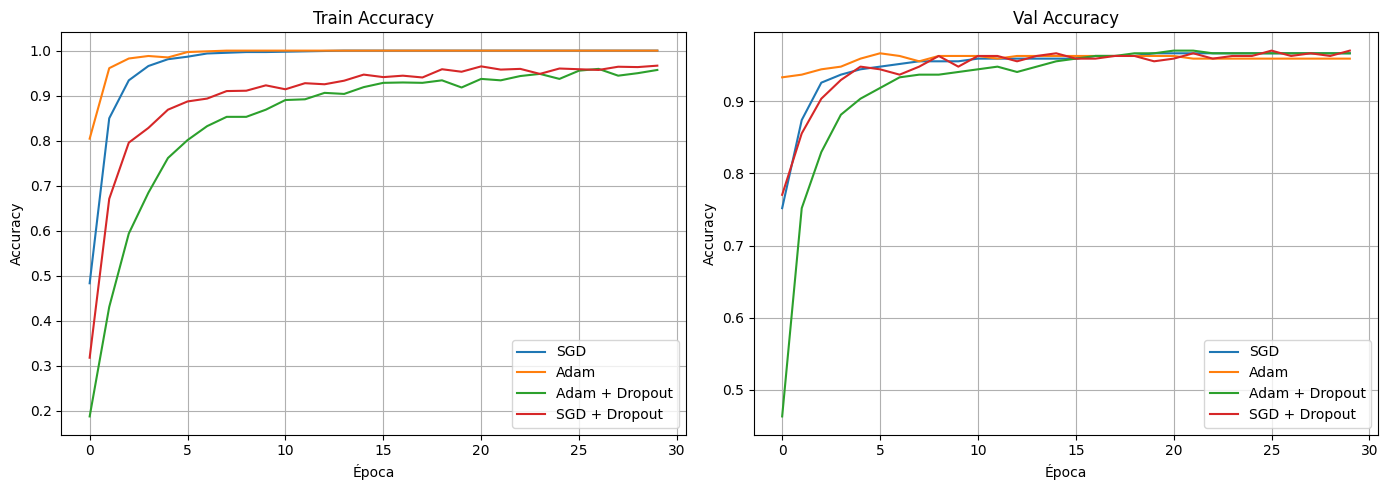

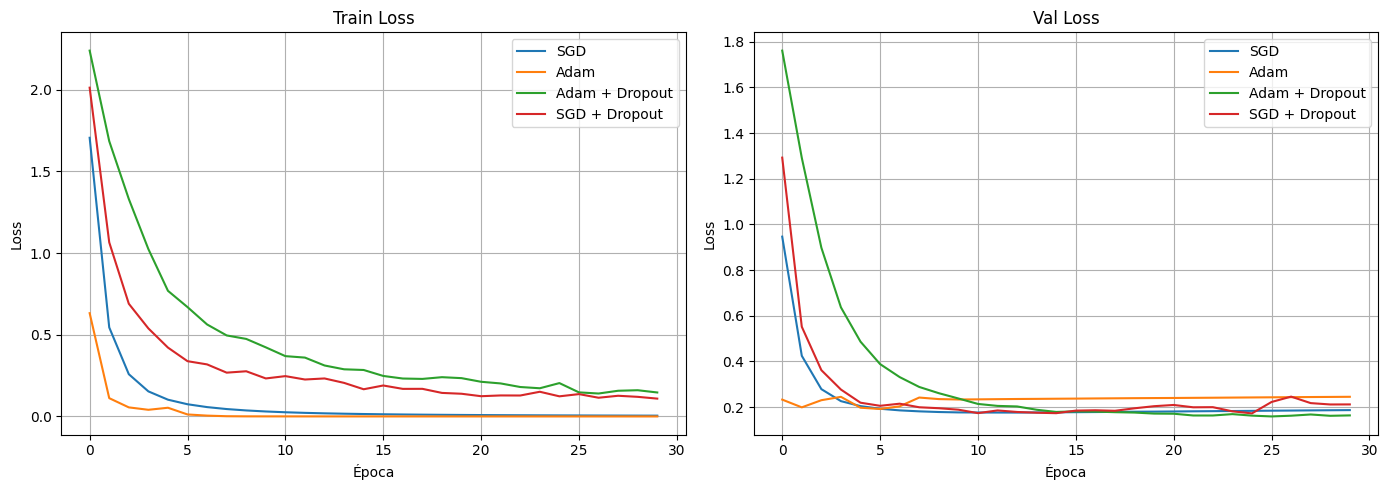

In [26]:
# Fase 7: Evaluación de resultados
def plot_history(histories, labels, metric='accuracy'):
    plt.figure(figsize=(14, 5))

    # Training
    plt.subplot(1, 2, 1)
    for h, lbl in zip(histories, labels):
        plt.plot(h.history[metric], label=lbl)
    plt.title(f'Train {metric.capitalize()}')
    plt.xlabel('Época')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid(True)

    # Validation
    plt.subplot(1, 2, 2)
    for h, lbl in zip(histories, labels):
        plt.plot(h.history[f'val_{metric}'], label=lbl)
    plt.title(f'Val {metric.capitalize()}')
    plt.xlabel('Época')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

histories = [
    history_sgd,
    history_adam,
    history_dropout,
    history_sgd_dropout
]

labels = [
    'SGD',
    'Adam',
    'Adam + Dropout',
    'SGD + Dropout'
]

plot_history(histories, labels, metric='accuracy')
plot_history(histories, labels, metric='loss')

In [27]:
models = {
    "SGD": model_sgd,
    "Adam": model_adam,
    "Adam + Dropout": model_dropout,
    "SGD + Dropout": model_sgd_dropout
}

print("\nRESULTADOS EN TEST\n")

for name, model in models.items():

    loss, acc = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    print(
        f"{name:15} | "
        f"Loss = {loss:.4f} | "
        f"Accuracy = {acc:.4f}"
    )



RESULTADOS EN TEST

SGD             | Loss = 0.0507 | Accuracy = 0.9815
Adam            | Loss = 0.0489 | Accuracy = 0.9815
Adam + Dropout  | Loss = 0.0678 | Accuracy = 0.9815
SGD + Dropout   | Loss = 0.0363 | Accuracy = 0.9889


Responder:

●  ¿Qué optimizador funcionó mejor?

El optimizador Adam presentó el mejor desempeño. Alcanzó una precisión de validación cercana al 96.3% en pocas épocas y mostró una convergencia más rápida que SGD. Además, obtuvo la mayor precisión en el conjunto de prueba (99.26%).

●  ¿Cómo influyó Dropout?

La incorporación de Dropout redujo la velocidad de aprendizaje del modelo, por lo que las curvas de entrenamiento crecieron más lentamente y la pérdida disminuyó de forma más gradual. Sin embargo, permitió que las curvas de entrenamiento y validación permanecieran más cercanas, favoreciendo una mejor capacidad de generalización.

●  ¿Hubo reducción del sobreajuste?

Sí, en los modelos sin Dropout (especialmente Adam), la precisión de entrenamiento alcanzó rápidamente el 100%, mientras que la precisión de validación se estabilizó alrededor del 96%, evidenciando cierto sobreajuste. Con Dropout, la diferencia entre entrenamiento y validación fue menor, lo que indica una reducción del sobreajuste y una mejor generalización del modelo

# 8)  Fase 8: Conclusiones

Responder:

1.  ¿Qué optimizador presentó mejor desempeño?

El optimizador Adam presentó el mejor desempeño general. Alcanzó una precisión de prueba del 99.26% y logró converger más rápidamente durante las primeras épocas de entrenamiento. Además, obtuvo altos valores de precisión con menos iteraciones que SGD.

2.  ¿Qué diferencias encontró entre SGD y Adam?

La principal diferencia fue la velocidad de convergencia. Adam alcanzó rápidamente altos niveles de precisión desde las primeras épocas gracias a su tasa de aprendizaje adaptativa. Por otro lado, SGD mostró un aprendizaje más gradual y requirió más épocas para alcanzar un rendimiento similar. Aunque ambos obtuvieron resultados finales cercanos, Adam fue más eficiente durante el entrenamiento.

3.  ¿Cómo afectó Dropout al rendimiento?

La técnica Dropout redujo ligeramente la precisión de entrenamiento y ralentizó la convergencia del modelo. Sin embargo, ayudó a mejorar la capacidad de generalización al evitar que la red dependiera excesivamente de ciertas neuronas. Esto permitió obtener modelos más robustos frente a datos no vistos.

4.  ¿Qué evidencia de overfitting observó?

Se observó overfitting principalmente en los modelos sin Dropout. Las gráficas muestran que la precisión de entrenamiento llegó rápidamente al 100%, mientras que la precisión de validación se estabilizó alrededor del 96%. Además, la pérdida de validación dejó de disminuir e incluso aumentó ligeramente en algunas etapas, indicando que el modelo continuaba aprendiendo detalles específicos del conjunto de entrenamiento sin mejorar su desempeño en validación.

5.  ¿Qué configuración considera más adecuada?

La configuración más adecuada fue Adam con Dropout. Aunque no alcanzó la mayor precisión absoluta, presentó un equilibrio entre rendimiento y capacidad de generalización, reduciendo el riesgo de sobreajuste.

# 7.  Preguntas de Control:

●  ¿Qué es un optimizador en Deep Learning?

Un optimizador es un algoritmo encargado de ajustar los pesos de una red neuronal durante el entrenamiento con el objetivo de minimizar la función de pérdida y mejorar la precisión de las predicciones.

●  ¿Cuál es la diferencia entre SGD y Adam?

SGD (Stochastic Gradient Descent) actualiza los pesos de forma gradual utilizando una tasa de aprendizaje fija, por lo que suele requerir más épocas para converger. Por su parte, Adam utiliza tasas de aprendizaje adaptativas para cada parámetro, logrando una convergencia más rápida y eficiente.

●  ¿Qué problema busca resolver Dropout?

Dropout busca reducir el overfitting desactivando aleatoriamente algunas neuronas durante el entrenamiento. Esto evita que la red dependa demasiado de características específicas y mejora su capacidad de generalización.

●  ¿Qué es overfitting?

El overfitting o sobreajuste ocurre cuando un modelo aprende demasiado bien los datos de entrenamiento, incluyendo ruido y patrones específicos, lo que provoca un peor rendimiento sobre datos nuevos o no vistos.

●  ¿Por qué se requiere validación?

La validación permite evaluar el desempeño del modelo durante el entrenamiento utilizando datos diferentes a los de entrenamiento. Esto ayuda a detectar sobreajuste y a comparar distintas configuraciones del modelo de manera objetiva.

●  ¿Qué optimizador obtuvo mejores resultados?
En esta práctica, Adam obtuvo los mejores resultados. Alcanzó una precisión de prueba del 99.26% y mostró una convergencia más rápida que SGD, logrando altos niveles de precisión en menos épocas de entrenamiento.